In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [11]:
def get_metrics(df: pd.DataFrame, column: str):
    mean_value = df[column].mean()
    std_value = df[column].std()
    # print(f"{column}: {mean_value:.3f} +- {std_value:.3f}")
    return mean_value, std_value

In [12]:
def get_results( folder_path: str ):
    # folder_path = "../results/modelV5.dim0.5.folds10_id20251126183757"
    # folder_path = "../results/modelV2.dim0.5.folds10_id20251120131323"
    listed_files = [file for file in os.listdir(folder_path)
                            if (file.endswith(".pkl") and 
                                not file.startswith(".sys.v#."))
                                ]
    all_metrics = []
    for file in listed_files:
        data = pd.DataFrame(pd.read_pickle(os.path.join(folder_path, file)))
        data = data[["file_path", "fold", "best_sp_value", "best_fa_value", "best_pd_value", "history"]]
        metrics = {"source_file": None,
                    "mean_sp": 0,
                    "std_sp": 0,
                    "mean_fa": 0,
                    "std_fa": 0,
                    "mean_pd": 0,
                    "std_pd": 0,
               
               }
        metrics["mean_sp"], metrics["std_sp"] = get_metrics(data, "best_sp_value")
        metrics["mean_fa"], metrics["std_fa"] = get_metrics(data, "best_fa_value")
        metrics["mean_pd"], metrics["std_pd"] = get_metrics(data, "best_pd_value")
        metrics["source_file"] = file
    
        metrics["folder_path"] = folder_path
        max_score_index = data['best_sp_value'].idxmax()
        row_of_max_value = data.loc[max_score_index]
        metrics["auc"] = row_of_max_value['history']['callbackMetrics']['auc_score']
        metrics["best_sp_value"] = row_of_max_value['best_sp_value']
        metrics["best_fa_value"] = row_of_max_value['best_fa_value']
        metrics["best_pd_value"] = row_of_max_value['best_pd_value']
        
        all_metrics.append(metrics)
    return all_metrics
        

In [13]:
all_metrics = []
folders_to_use = [
    "../results/modelV5.dim0.5.folds10_id20251126183757",
    "../results/modelV4.dim0.5.folds10_id20251125151554",
    "../results/modelV3.dim0.5.folds10_id20251117001936",
    "../results/modelV2.dim0.5.folds10_id20251120131323",
]
for folder_path in folders_to_use:
    current_results = get_results(folder_path)
    all_metrics  = all_metrics + current_results

In [14]:
def extract_percentage(row) -> str:
    match = re.search(r"dim(\d+\.\d+)", row['folder_path'])
    if match:
        return match.group(1)
    return None # Retorna None se o padrão não for encontrado

def extract_model_name(row) -> str:
    match = re.search(r"(modelV\d+)", row['folder_path'])
    if match:
        return match.group(1)
    return None

def extract_et(row) -> str:
    match = re.search(r"iet(\d+)\.ieta(\d+)", row['source_file'])
    if match:
        return int(match.group(1))
    return None

def extract_eta(row) -> str:
    match = re.search(r"iet(\d+)\.ieta(\d+)", row['source_file'])
    if match:
        # Note: Aqui usamos o grupo 2 da mesma expressão regular
        return int(match.group(2))
    return None

In [15]:
df = pd.DataFrame(all_metrics)

df['percentage'] = df.apply(extract_percentage, axis=1)
df['model_name'] = df.apply(extract_model_name, axis=1)
df['et'] = df.apply(extract_et, axis=1)
df['eta'] = df.apply(extract_eta, axis=1)

In [16]:
df

,source_file,mean_sp,std_sp,mean_fa,std_fa,mean_pd,std_pd,folder_path,auc,best_sp_value,best_fa_value,best_pd_value,percentage,model_name,et,eta
0,iet0.ieta0.pkl,0.811998,0.001928,0.117017,0.007820,0.744018,0.007032,../results/modelV5.dim0.5.folds10_id2025112618...,0.869108,0.816436,0.105014,0.741496,0.5,modelV5,0,0
1,iet1.ieta0.pkl,0.788204,0.001837,0.131875,0.007394,0.712178,0.007939,../results/modelV5.dim0.5.folds10_id2025112618...,0.851554,0.790625,0.134990,0.719587,0.5,modelV5,1,0
2,iet2.ieta0.pkl,0.817775,0.001406,0.120128,0.010428,0.758003,0.009413,../results/modelV5.dim0.5.folds10_id2025112618...,0.879518,0.820548,0.107072,0.751230,0.5,modelV5,2,0
3,iet3.ieta0.pkl,0.805875,0.002944,0.132962,0.010952,0.746990,0.007305,../results/modelV5.dim0.5.folds10_id2025112618...,0.874124,0.810785,0.124352,0.748420,0.5,modelV5,3,0
4,iet4.ieta0.pkl,0.799075,0.002776,0.143966,0.011780,0.744131,0.008819,../results/modelV5.dim0.5.folds10_id2025112618...,0.870412,0.801665,0.142080,0.747319,0.5,modelV5,4,0
5,iet5.ieta0.pkl,0.847960,0.002398,0.114817,0.004680,0.811541,0.003282,../results/modelV5.dim0.5.folds10_id2025112618...,0.909097,0.853261,0.105338,0.812841,0.5,modelV5,5,0
6,iet6.ieta0.pkl,0.823697,0.001756,0.132199,0.004381,0.780753,0.004408,../results/modelV5.dim0.5.folds10_id2025112618...,0.889129,0.826563,0.125871,0.780328,0.5,modelV5,6,0
7,iet7.ieta0.pkl,0.801835,0.003006,0.135286,0.012885,0.741411,0.012095,../results/modelV5.dim0.5.folds10_id2025112618...,0.868918,0.805764,0.110034,0.725750,0.5,modelV5,7,0
8,iet0.ieta0.pkl,0.813214,0.001715,0.105664,0.006779,0.735974,0.006429,../results/modelV4.dim0.5.folds10_id2025112515...,0.869099,0.816709,0.100112,0.737567,0.5,modelV4,0,0
9,iet1.ieta0.pkl,0.790046,0.001690,0.127586,0.007391,0.711792,0.006682,../results/modelV4.dim0.5.folds10_id2025112515...,0.852929,0.792959,0.119006,0.709564,0.5,modelV4,1,0


In [17]:
et_axis = ["0: 25->30", "1: 30->35", "2: 35->40", 
           "3: 40->45", "4: 45->50", "5: 50->60", 
           "6: 60->80", "7: 80->100"]

eta_axis = ["0: 0.00->0.60",
"1: 0.60->0.80",
"2: 0.80->1.15",
"3: 1.15->1.37",
"4: 1.37->1.52",
"5: 1.52->1.81",
"6: 1.81->2.01",
"7: 2.01->2.37",
"8: 2.37->2.47"]

<>:15: SyntaxWarning: invalid escape sequence '\e'
<>:17: SyntaxWarning: invalid escape sequence '\e'
<>:15: SyntaxWarning: invalid escape sequence '\e'
<>:17: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_404/3878126175.py:15: SyntaxWarning: invalid escape sequence '\e'
  ax.set_ylabel("$\eta$ (eta)")
/tmp/ipykernel_404/3878126175.py:17: SyntaxWarning: invalid escape sequence '\e'
  ax.set_title(f"[{model_name}] Metrics by pair ($E_T$, $\eta$)")


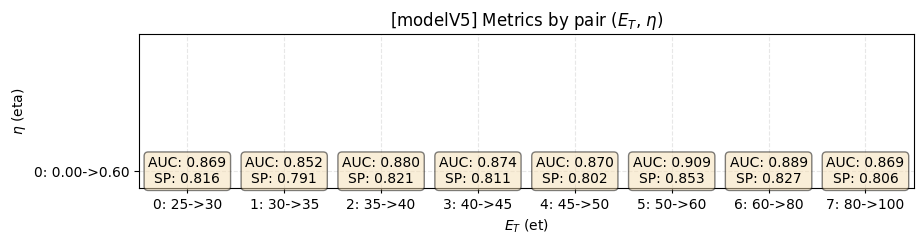

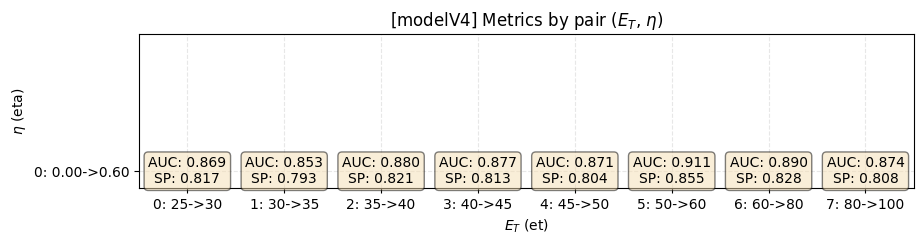

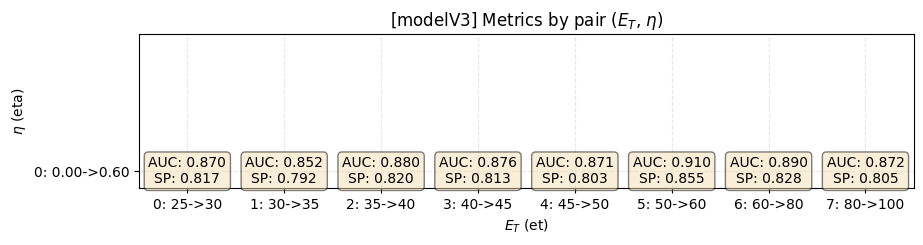

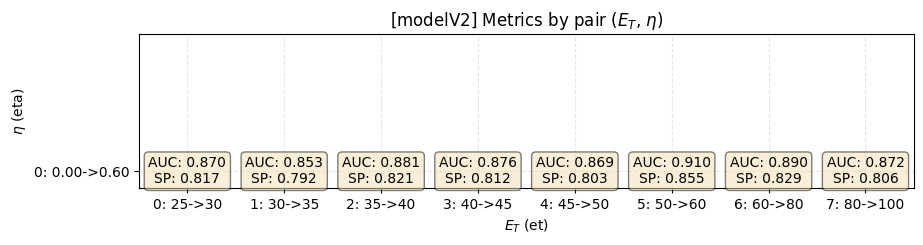

In [18]:

def plot_metrics_grid(df, model_name):
    fig, ax = plt.subplots(figsize=(10, 2))
    unique_et = df['et'].unique()
    unique_eta = df['eta'].unique()
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

    for _, row in df.iterrows():
        label = f"AUC: {row['auc']:.3f}\nSP: {row['best_sp_value']:.3f}"
        
        ax.text(row['et'], row['eta'], label, 
                ha='center', va='center', 
                bbox=props, fontsize=10)
    ax.text(row['et']+2, row['eta']+2, "")

    ax.set_ylabel("$\eta$ (eta)")
    ax.set_xlabel("$E_T$ (et)")
    ax.set_title(f"[{model_name}] Metrics by pair ($E_T$, $\eta$)")
    
    margin_x = 0.5
    margin_y = 1.0
    ax.set_xlim(min(unique_eta) - margin_x, max(unique_eta) + margin_x + 7)
    ax.set_ylim(min(unique_et) - margin_y, max(unique_et) + margin_y)
    
    ax.set_yticks(sorted(unique_eta), eta_axis[:len(unique_eta)])
    ax.set_xticks(sorted(unique_et), et_axis[:len(unique_et)])
    
    ax.grid(True, linestyle='--', alpha=0.3)
    
    return fig

for model_name in df['model_name'].unique():
    filtered_df = df[df["model_name"] == model_name]
    fig = plot_metrics_grid(filtered_df, model_name)

In [23]:
def get_et_axis():
    return ["0: 25->30", "1: 30->35", "2: 35->40", 
           "3: 40->45", "4: 45->50", "5: 50->60", 
           "6: 60->80", "7: 80->100"]

def get_eta_axis():
    return["0: 0.00->0.60",
    "1: 0.60->0.80",
    "2: 0.80->1.15",
    "3: 1.15->1.37",
    "4: 1.37->1.52",
    "5: 1.52->1.81",
    "6: 1.81->2.01",
    "7: 2.01->2.37",
    "8: 2.37->2.47"]


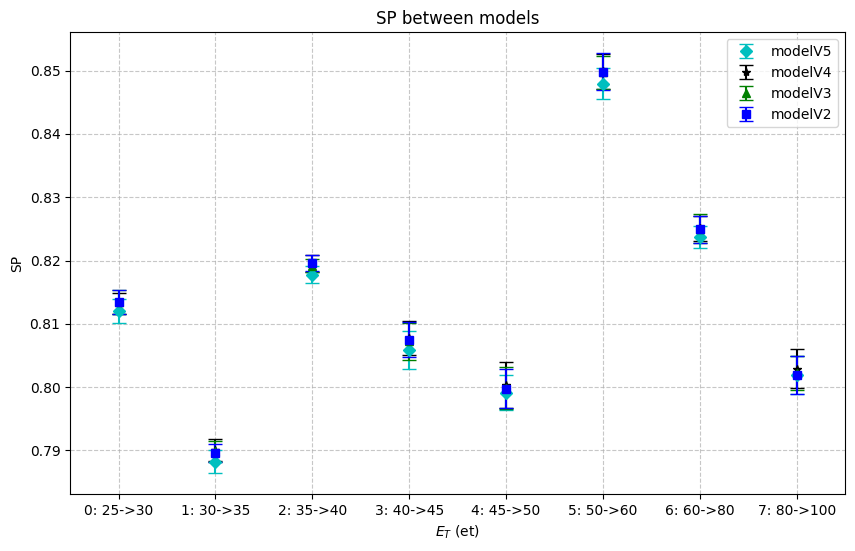

In [51]:
fmts = ['ro', 'bs', 'g^', 'k*', 'cD']
fig, ax = plt.subplots(figsize=(10, 6))
plot_et = True
for model_name in df['model_name'].unique():
    filtered_df = df[df["model_name"] == model_name]
    fmt = fmts.pop()
    filtered_df_eta = filtered_df
    ax.errorbar(filtered_df_eta["et"] if plot_et else filtered_df_eta["eta"],  
                filtered_df_eta["mean_sp"], 
                yerr=filtered_df_eta["std_sp"], fmt=fmt, 
                capsize=5, label=f'{model_name}')

    margin_x = 0.5
    margin_y = 1.0
    unique_et = filtered_df_eta['et'].unique()
    unique_eta = filtered_df_eta['eta'].unique()
    if plot_et:
        ax.set_xlim(min(unique_eta) - margin_x, max(unique_eta) + margin_x + 7)
        ax.set_xticks(sorted(unique_et), get_et_axis()[:len(unique_et)])
    else:
        ax.set_xlim(min(unique_et) - margin_y, max(unique_et) + margin_y)
        ax.set_xticks(sorted(unique_eta), get_eta_axis()[:len(unique_eta)])
    
    ax.set_title('SP between models')
    ax.set_ylabel('SP')
    ax.set_xlabel("$E_T$ (et)")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [26]:
filtered_df_eta

,source_file,mean_sp,std_sp,mean_fa,std_fa,mean_pd,std_pd,folder_path,auc,best_sp_value,best_fa_value,best_pd_value,percentage,model_name,et,eta
7,iet7.ieta0.pkl,0.801835,0.003006,0.135286,0.012885,0.741411,0.012095,../results/modelV5.dim0.5.folds10_id2025112618...,0.868918,0.805764,0.110034,0.72575,0.5,modelV5,7,0
